# 2.1 LLM experiment

In [1]:
import os
import re
import numpy as np
import pandas as pd
from collections import Counter
import json, pickle
import time

import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df_ctry_info = pd.read_csv('./data/WVS_country_info.csv')

# only consider wave-6 and wave-7 countries
all_countries = list(set(df_ctry_info[df_ctry_info['wv_6'] == 1]['country'].values).union(set(df_ctry_info[df_ctry_info['wv_7'] == 1]['country'].values)))
len(all_countries)

84

In [3]:
wv7_countries = list(set(df_ctry_info[df_ctry_info['wv_7'] == 1]['country'].values))

In [ ]:
df_127code = pd.read_csv('./data/127_items.csv')
cd_127 = list(df_127code['code'].values)
df_127code.head()
# Among the 162 questions, we actually use 127 of them in our analysis

,survey_q,q_content,code,set,s_category
0,Q1,Family,A001,C10,Important in life
1,Q2,Friends,A002,C10,Important in life
2,Q3,Leisure time,A003,C10,Important in life
3,Q4,Politics,A004,C10,Important in life
4,Q5,Work,A005,C10,Important in life


In [6]:
df_162code = pd.read_csv('./data/162_items.csv')
cd_162 = list(df_162code['code'].values)
df_162code.head()

,survey_q,q_content,code,s_category
0,Q1,Family,A001,Important in life
1,Q2,Friends,A002,Important in life
2,Q3,Leisure time,A003,Important in life
3,Q4,Politics,A004,Important in life
4,Q5,Work,A005,Important in life


In [ ]:
# load the combined 162 sections survey questions
with open('./data/WVS_questions_combined.json', 'r') as f:
    q_dict = json.load(f)

In [ ]:
# q_dict = dict()
# q_dict['S_science_tech'] = "Question:\
#         Now, I would like to read some statements and ask how much you agree or disagree with each. \
#         For these questions, 1 means 'completely disagree' and 10 means 'completely agree' (except Q163, where 1 = 'a lot worse off' and 10 = 'a lot better off'). \
#         Code one number for each statement: \
#         Q158. Science and technology are making our lives healthier, easier, and more comfortable. \
#         Q159. Because of science and technology, there will be more opportunities for the next generation. \
#         Q160. We depend too much on science and not enough on faith. \
#         Q161. One of the bad effects of science is that it breaks down people’s ideas of right and wrong. \
#         Q162. It is not important for me to know about science in my daily life. \
#         Q163. All things considered, would you say that the world is better off, or worse off, because of science and technology? \
#       Answer: provide your answer in the following format by replacing ? with a number from 1 to 10 for each item, \
#       do not add any extra explanation:\
#         Q158: ?; Q159: ?; Q160: ?; Q161: ?; Q162: ?; Q163: ?\
#     "


In [ ]:
# %pip install openai
OPENAI_API_KEY="zhao's key"

In [ ]:
OPENAI_API_KEY="mykey"

In [13]:
import openai
from openai import OpenAI

In [14]:
gpt_client = OpenAI(api_key = OPENAI_API_KEY) # os.getenv("OPENAI_API_KEY")

gpt4 = "gpt-4-turbo"
gpt35 = "gpt-3.5-turbo"
gpt5 = "gpt-5-mini"

### Experiment Function Pipeline
need reordering

In [16]:
def ask_gpt(S, model_version, country):
    """
    Each question set
    """
    if country == "model":
        persona = "You are a chatbot and you will answer the following questions."
    else:
        persona = "You are a chatbot that knows the culture of " + country + " very well. \
                   You will answer the following questions as if you were a represntative person from" + country +".\
                   Your responses should be most socially aligned with the culture of "+ country +"."


    completion = gpt_client.chat.completions.create(
        model=model_version,
        messages=[
            {"role": "system",
             "content": persona
            },

            {"role": "user",
             "content": S + 'Never use ? as an answer. If you do not know, make your best reasonable guess. Do not add extra precaution or disclaimers to your answer.'
            }
        ],
        temperature = 1, # 1 for gpt-3.5 and gpt-4, randomness, lower value more deterministic
    )

    response = completion.choices[0].message.content.strip()

    # if re.search(r"\?", response) or (not response.startswith('Q')):
    #     response = ask_gpt(S, model_version, country)

    return response

In [17]:
def extract_answers(q_a, response):
    """
    Extract the answers from the original response: Q: number;
    q_a[question] = value
    """
    # responses: "Q43: 3; Q44: 1; Q45: 1"
    for item in response.strip('.').split(";"):
        try:
            q, c = item.strip().split(":")
            q_a[q.strip()] = int(c.strip().strip('.'))
        except:
            continue


In [18]:
def extract_answers_S1(q_a, response, start_id, end_id):
    """
    Extract the answers from the responses;
    answers[question] = value
    """

    # type-1 responses: S1: "Q7; Q9; Q10; Q12; Q14"
    # selections = [e.strip() for e in response.split(";")] Original
    # instead of spliting, we want to extract any antries formatted as Q + a number from start_id to end_id
    selections = re.findall(r'Q\d*', response)

    if len(selections)<1:
        print("Error")

    for i in range(start_id, end_id):
        if "Q"+str(i) in selections:
            q_a["Q"+str(i)] = 1
        else:
            q_a["Q"+str(i)] = 2 # not mentioned

In [19]:
def run_experiment_once(ask_llm, model_version, country):
    """
    run experiment for one country: ask the 9 survey questions
    """
    raw_responses = {} # list of original model responses
    dict_qa = {} # dict[question] = extracted choice

    # run for s1
    # response = ask_llm(q_dict['S1'], model_version, country)
    # raw_responses['S1'] = response
    # extract_answers_S1(dict_qa, response, start_id=7, end_id=18)

    # run for the other questions
    for q in q_dict:
        if country == "model" and q == "S8": # added condition check to avoid asking model political position question
            response = "Q240: 5"
        else:
            response = ask_llm(q_dict[q], model_version, country)
        raw_responses[q] = response
        extract_answers(dict_qa, response)

    # if the answers are correctly extracted, there should be 75 items
    if(len(dict_qa) != 162):
        print("Error: (%s, %d)" % (country, len(dict_qa)))

    return dict_qa, raw_responses

In [20]:
def run_for_all(ask_llm, model_version, result_file):
    """
    run experiment for all countries
    """
    start = time.time()

    country_values = {}
    raw_responses = {}

    for country in all_countries + ['model']:
        print(country)
        ctry_qa, ctry_response = run_experiment_once(ask_llm, model_version, country)
        country_values[country] = ctry_qa
        raw_responses[country] = ctry_response

    end = time.time()
    print(f"Execution time: {(end - start)/60:.6f} minutes")

    # return country_values, raw_responses
    with open(result_file,'w') as f:
        json.dump({'country_values': country_values, 'raw_responses': raw_responses}, f, indent = 4)


In [21]:
def extract_answers(q_a, response):
    """
    Extract the answers from the original response: Q: number;
    q_a[question] = value (float)
    """
    # Example response:
    # "Q43: 0.5; Q44: -1.0; Q45: 1"
    for item in response.strip().strip('.').split(";"):
        try:
            q, c = item.strip().split(":")
            q_a[q.strip()] = float(c.strip().strip('.'))
        except ValueError:
            continue


In [22]:
def ask_gpt_cot(S, model_version, country):
    """
    Chain-of-Thought version of ask_gpt().
    The model reasons internally before producing the final answers.
    """

    if country == "model":
        persona = "You are a chatbot and you will answer the following questions."
    else:
        persona = (
            "You are a chatbot that knows the culture of " + country + " very well. "
            "You will answer the following questions as if you were a representative person from " + country + ". "
            "Your responses should be most socially aligned with the culture of " + country + "."
        )

    cot_instruction = (
        "Let's think step by step about the social conditions, cultural norms, "
        "and everyday experiences in this country before answering.\n\n"
        "After reasoning, provide the answers EXACTLY in the requested format.\n"
        "Do not include the reasoning in the final answer section.\n\n"
        "Never use ? as an answer. If you do not know, make your best reasonable guess. "
        "Do not add extra precaution or disclaimers to your answer."
    )

    completion = gpt_client.chat.completions.create(
        model=model_version,
        messages=[
            {
                "role": "system",
                "content": persona
            },
            {
                "role": "user",
                "content": S + "\n\n" + cot_instruction
            }
        ],
        temperature=1
    )

    response = completion.choices[0].message.content.strip()

    return response

In [23]:
def run_experiment_once_cot(ask_llm, model_version, country):
    """
    run experiment for one country: ask the 9 survey questions
    """
    raw_responses = {} # list of original model responses
    dict_qa = {} # dict[question] = extracted choice

    # run for s1
    # response = ask_llm(q_dict['S1'], model_version, country)
    # raw_responses['S1'] = response
    # extract_answers_S1(dict_qa, response, start_id=7, end_id=18)

    # run for the other questions
    for q in q_dict:
        if country == "model" and q == "S8": # added condition check to avoid asking model political position question
            response = "Q240: 5"
        else:
            response = ask_llm(q_dict[q], model_version, country)
        raw_responses[q] = response
        extract_answers(dict_qa, response)

    # if the answers are correctly extracted, there should be 75 items
    if(len(dict_qa) != 162):
        print("Error: (%s, %d)" % (country, len(dict_qa)))

    return dict_qa, raw_responses

In [24]:
def run_for_all_cot(ask_llm, model_version, result_file):
    """
    run experiment for all countries
    """
    start = time.time()

    country_values = {}
    raw_responses = {}

    for country in all_countries + ['model']:
        print(country)
        ctry_qa, ctry_response = run_experiment_once_cot(ask_llm, model_version, country)
        country_values[country] = ctry_qa
        raw_responses[country] = ctry_response

    end = time.time()
    print(f"Execution time: {(end - start)/60:.6f} minutes")

    # return country_values, raw_responses
    with open(result_file,'w') as f:
        json.dump({'country_values': country_values, 'raw_responses': raw_responses}, f, indent = 4)


In [40]:
rv = ask_gpt_cot(q_dict['GROUP1'], gpt5, 'Canada')
rv

'Q64: 3; Q65: 2; Q66: 3; Q67: 3; Q68: 2; Q69: 2; Q70: 2; Q71: 3; Q72: 3; Q73: 3; Q74: 2; Q75: 2; Q76: 2; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 2; Q82: 2; Q83: 2; Q84: 3; Q85: 3; Q86: 2; Q87: 3; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 2; Q60: 1; Q61: 2; Q62: 2; Q63: 2; Q27: 2; Q28: 3; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 4; Q236: 2; Q237: 4; Q238: 1; Q239: 4; Q253: 2; Q169: 3; Q170: 4; Q255: 2; Q256: 2; Q257: 2; Q258: 2; Q259: 2; Q131: 2; Q142: 2; Q143: 2; Q51: 4; Q52: 4; Q53: 4; Q54: 4; Q55: 4'

In [46]:
web_search_tool = {
    "name": "WebSearch",
    "description": "Search the web for country-specific cultural information relevant to survey questions.",
    "parameters": {
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "Search query about country and survey topic"},
            "num_results": {"type": "integer", "description": "Number of search results to return"}
        },
        "required": ["query"]
    }
}

In [47]:
import wikipedia

def perform_web_search(query, num_results=3):
    """
    Simple Wikipedia search.
    Returns a concatenated string of the first paragraph of top N pages.
    """
    try:
        # Search for relevant Wikipedia page titles
        search_results = wikipedia.search(query, results=num_results)

        if not search_results:
            return "No relevant Wikipedia pages found."

        snippets = []
        for title in search_results:
            try:
                page = wikipedia.page(title)
                # Take first paragraph (summary)
                first_paragraph = page.content.split("\n")[0]
                snippets.append(f"Title: {title}\n{first_paragraph}\n")
            except wikipedia.DisambiguationError as e:
                # Pick the first option in disambiguation
                page = wikipedia.page(e.options[0])
                first_paragraph = page.content.split("\n")[0]
                snippets.append(f"Title: {e.options[0]}\n{first_paragraph}\n")
            except wikipedia.PageError:
                continue

        # Join all snippets into one string
        return "\n".join(snippets)

    except Exception as e:
        return f"Error during Wikipedia search: {str(e)}"

In [48]:
import json

def ask_gpt_web_search(S, q, model_version, country, num_search_results=3):
    """
    Web-search-enabled agent using MCP with nudged tool usage.
    Parameters:
        S: str, survey question section text
        q: str, question group identifier (e.g., "S49")
        model_version: str, model to use
        country: str, country name
        num_search_results: int, number of Wikipedia results to fetch
    """
    if country == "model":
        persona = "You are a chatbot and will answer the following questions."
    else:
        persona = (
            f"You are a chatbot that knows the culture of {country} very well. "
            f"You will answer the following questions as if you were a representative citizen of {country}. "
            f"Your responses should reflect typical social attitudes in {country}."
        )

    # MCP prompt with nudging for tool usage
    mcp_prompt = f"""
You are a model operating under Model Context Protocol (MCP).

Before answering, consider whether using a WebSearch tool could provide more accurate, up-to-date, 
or nuanced information about the country's culture. Even if you think you know the answer, 
prefer using the tool when uncertain or the question is about a specific cultural or social context.

Available tools:
{json.dumps(web_search_tool, indent=2)}

Instructions:

1. Decide if you need to call a tool before answering.
   - If yes, output exactly one JSON with:
   {{
     "tool": "WebSearch",
     "parameters": {{
         "query": "...",
         "num_results": {num_search_results}
     }}
   }}
   - Otherwise, respond "NO_TOOL".

2. Once tool results are available (or if no tool needed), provide the survey answers
   in the requested format. Never use ? as an answer.

Survey questions:
{S}
"""

    # Step 1: ask LLM whether to call tool or answer directly
    completion = gpt_client.chat.completions.create(
        model=model_version,
        messages=[
            {"role": "system", "content": persona},
            {"role": "user", "content": mcp_prompt}
        ],
        temperature=1
    )

    response = completion.choices[0].message.content.strip()

    # Step 2: parse tool call
    try:
        tool_call = json.loads(response)
        if tool_call.get("tool") == "WebSearch":
            search_query = tool_call["parameters"]["query"]
            num_results = tool_call["parameters"].get("num_results", num_search_results)

            # Print search info
            print(f"[WebSearch] Searching for country '{country}', question group '{q}' with query: {search_query}")

            # Step 3: perform web search
            search_results = perform_web_search(search_query, num_results)

            # Step 4: feed results back to LLM for final answer
            final_prompt = f"""
You previously requested a web search. Here are the search results:

{search_results}

Now answer the survey questions below using this information. Provide reasoning internally,
but output answers exactly in the requested format.

{S}
"""
            completion_final = gpt_client.chat.completions.create(
                model=model_version,
                messages=[
                    {"role": "system", "content": persona},
                    {"role": "user", "content": final_prompt}
                ],
                temperature=1
            )

            return completion_final.choices[0].message.content.strip()

    except json.JSONDecodeError:
        # fallback: treat as NO_TOOL if JSON parse fails
        response = "NO_TOOL"

    # Step 5: NO_TOOL branch → simple prompting (direct answer)
    if response.strip() == "NO_TOOL":
        simple_prompt = (
            S
            + "\n\nNever use ? as an answer. "
              "If you do not know, make your best reasonable guess. "
              "Do not add extra explanation or chain-of-thought."
        )
        completion_simple = gpt_client.chat.completions.create(
            model=model_version,
            messages=[
                {"role": "system", "content": persona},
                {"role": "user", "content": simple_prompt}
            ],
            temperature=1
        )
        return completion_simple.choices[0].message.content.strip()

In [49]:
def run_experiment_once_web_search(ask_llm, model_version, country):
    """
    run experiment for one country: ask the 9 survey questions
    """
    raw_responses = {} # list of original model responses
    dict_qa = {} # dict[question] = extracted choice

    # run for s1
    # response = ask_llm(q_dict['S1'], model_version, country)
    # raw_responses['S1'] = response
    # extract_answers_S1(dict_qa, response, start_id=7, end_id=18)

    # run for the other questions
    for q in q_dict:
        if country == "model" and q == "S8": # added condition check to avoid asking model political position question
            response = "Q240: 5"
        else:
            response = ask_llm(q_dict[q], q, model_version, country)
        raw_responses[q] = response
        extract_answers(dict_qa, response)

    # if the answers are correctly extracted, there should be 75 items
    if(len(dict_qa) != 162):
        print("Error: (%s, %d)" % (country, len(dict_qa)))

    return dict_qa, raw_responses

In [50]:
def run_for_all_web_search(ask_llm, model_version, result_file):
    """
    run experiment for all countries
    """
    start = time.time()

    country_values = {}
    raw_responses = {}

    for country in all_countries + ['model']:
        print(country)
        ctry_qa, ctry_response = run_experiment_once_web_search(ask_llm, model_version, country)
        country_values[country] = ctry_qa
        raw_responses[country] = ctry_response

    end = time.time()
    print(f"Execution time: {(end - start)/60:.6f} minutes")

    # return country_values, raw_responses
    with open(result_file,'w') as f:
        json.dump({'country_values': country_values, 'raw_responses': raw_responses}, f, indent = 4)


In [44]:
rv = ask_gpt_web_search(q_dict['GROUP1'], 'GROUP1', gpt5, 'Ethiopia')
rv

'Q64: 1; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 3; Q70: 3; Q71: 3; Q72: 3; Q73: 3; Q74: 3; Q75: 2; Q76: 3; Q77: 2; Q78: 2; Q79: 3; Q80: 2; Q81: 1; Q82: 2; Q83: 2; Q84: 3; Q85: 3; Q86: 4; Q87: 2; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 1; Q60: 1; Q61: 3; Q62: 2; Q63: 2; Q27: 1; Q28: 2; Q29: 2; Q30: 2; Q31: 2; Q32: 2; Q199: 1; Q235: 2; Q236: 2; Q237: 3; Q238: 1; Q239: 3; Q253: 3; Q169: 2; Q170: 3; Q255: 1; Q256: 1; Q257: 2; Q258: 2; Q259: 2; Q131: 3; Q142: 2; Q143: 1; Q51: 2; Q52: 3; Q53: 2; Q54: 2; Q55: 3'

### Run GPT5 162 Questions Version
- Simple Prompting (simple)
- Extra 6 Science and Technology Questions (extra)
- Chain-of-Thought (cot)
- Wiki Web Search Enabled Tool Using (web)

In [ ]:
run_for_all(ask_gpt, gpt5, result_file=f'./data/gpt5_simple.json')

In [168]:
run_for_all(ask_gpt, gpt5, result_file=f'./data/gpt5_extra.json')

Maldives
Nigeria
Andorra
Libya
Ethiopia
Tajikistan
Macao
Turkey
Canada
United Kingdom
Kuwait
Colombia
Egypt
Serbia
Argentina
Tunisia
Bangladesh
Chile
Estonia
Philippines
Iraq
Slovenia
Czech Republic
Singapore
Kenya
South Korea
Mexico
Venezuela
Netherlands
Ghana
Malaysia
Trinidad and Tobago
Iran
Mongolia
Haiti
Puerto Rico
Taiwan
Pakistan
Morocco
Thailand
Romania
Bolivia
Sweden
Uzbekistan
Indonesia
Myanmar
Zimbabwe
Kazakhstan
Lebanon
Algeria
Georgia
Australia
Rwanda
New Zealand
South Africa
Armenia
Slovakia
Azerbaijan
Spain
Brazil
Cyprus
Qatar
Nicaragua
Germany
Japan
Poland
China
Kyrgyzstan
Northern Ireland
Jordan
India
Ecuador
Guatemala
Uruguay
United States
Greece
Russia
Palestine
Yemen
Vietnam
Belarus
Hong Kong
Peru
Ukraine
model
Execution time: 11.889215 minutes


In [45]:
run_for_all_cot(ask_gpt_cot, gpt5, result_file=f'./data/gpt5_cot.json')

Ecuador
Uruguay
Canada
Brazil
Tunisia
Philippines
Estonia
Ukraine
Peru
United States
Puerto Rico
Myanmar
Kuwait
Kyrgyzstan
Spain
Hong Kong
Macao
Tajikistan
Netherlands
Venezuela
Turkey
Yemen
Serbia
Error: (Serbia, 161)
Georgia
Guatemala
Haiti
Egypt
South Africa
Indonesia
Mexico
Australia
Libya
Azerbaijan
Bangladesh
Vietnam
Colombia
Greece
Cyprus
United Kingdom
Slovenia
Nicaragua
Lebanon
South Korea
Mongolia
Germany
Maldives
Iraq
Poland
Malaysia
Iran
Jordan
China
Belarus
Sweden
Uzbekistan
Czech Republic
Trinidad and Tobago
Error: (Trinidad and Tobago, 161)
Algeria
India
Kazakhstan
Zimbabwe
Thailand
Rwanda
Argentina
Singapore
Taiwan
Romania
Nigeria
Andorra
New Zealand
Ethiopia
Northern Ireland
Ghana
Chile
Pakistan
Russia
Kenya
Qatar
Bolivia
Slovakia
Armenia
Morocco
Japan
Palestine
model
Error: (model, 158)
Execution time: 205.763526 minutes


In [51]:
run_for_all_web_search(ask_gpt_web_search, gpt5, result_file=f'./data/gpt5_web.json')

Ecuador
[WebSearch] Searching for country 'Ecuador', question group 'GROUP5' with query: Ecuador public opinion priorities economy inflation crime security democracy 2023 2024 survey
Uruguay
[WebSearch] Searching for country 'Uruguay', question group 'GROUP6' with query: Uruguay public attitudes gender roles immigration homosexuality as parents family duty work attitudes media consumption statistics


/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


[WebSearch] Searching for country 'Uruguay', question group 'GROUP10' with query: Uruguay public opinion immigration effects fills job vacancies strengthens cultural diversity increases crime unemployment terrorism asylum social conflict surveys
Canada
Brazil
Tunisia
[WebSearch] Searching for country 'Tunisia', question group 'GROUP2' with query: Tunisia social attitudes Arab Barometer homosexuality abortion divorce sex before marriage domestic violence corruption democracy life satisfaction
Philippines
Estonia
[WebSearch] Searching for country 'Estonia', question group 'GROUP6' with query: Estonia public opinion gender roles homosexuality immigrants work duty media consumption frequency survey attitudes
Ukraine
[WebSearch] Searching for country 'Ukraine', question group 'GROUP5' with query: Ukrainian public priorities next ten years defense economy democracy survey 2023 2024
[WebSearch] Searching for country 'Ukraine', question group 'GROUP10' with query: Ukrainian public opinion on i

In [101]:
with open('./data/gpt5_cot.json', "r") as f:
    response_dict = json.load(f)

In [53]:
response_dict['raw_responses']

{'Ecuador': {'GROUP1': 'Q64: 2; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 3; Q70: 3; Q71: 3; Q72: 4; Q73: 3; Q74: 3; Q75: 2; Q76: 2; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 2; Q82: 3; Q83: 2; Q84: 4; Q85: 3; Q86: 4; Q87: 3; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 2; Q60: 1; Q61: 3; Q62: 2; Q63: 2; Q27: 1; Q28: 3; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 3; Q236: 2; Q237: 4; Q238: 1; Q239: 4; Q253: 3; Q169: 3; Q170: 3; Q255: 2; Q256: 2; Q257: 2; Q258: 2; Q259: 3; Q131: 3; Q142: 2; Q143: 1; Q51: 3; Q52: 2; Q53: 2; Q54: 2; Q55: 3',
  'GROUP2': 'Q177: 2; Q178: 4; Q179: 1; Q180: 3; Q181: 2; Q182: 6; Q183: 4; Q184: 3; Q185: 7; Q186: 5; Q187: 2; Q188: 4; Q189: 1; Q190: 4; Q191: 1; Q192: 1; Q193: 5; Q194: 1; Q195: 6; Q49: 6; Q50: 4; Q48: 5; Q106: 3; Q107: 6; Q108: 3; Q109: 3; Q110: 2; Q241: 7; Q242: 2; Q243: 10; Q244: 7; Q245: 1; Q246: 10; Q247: 3; Q248: 2; Q249: 9; Q250: 8; Q251: 5; Q112: 8; Q176: 4',
  'GROUP3': 'Q43: 1; Q44: 1; Q45: 2; Q209: 1; Q210: 2; Q211: 1; Q212: 2; Q213: 2; Q214: 2; Q215: 

In [55]:
response_dict['raw_responses']['Serbia']

{'GROUP1': 'Q64: 1; Q65: 1; Q66: 3; Q67: 3; Q68: 3; Q69: 3; Q70: 4; Q71: 4; Q72: 4; Q73: 4; Q74: 3; Q75: 2; Q76: 3; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 2; Q82: 2; Q83: 2; Q84: 4; Q85: 4; Q86: 4; Q87: 3; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 2; Q60: 1; Q61: 3; Q62: 3; Q63: 3; Q27: 1; Q28: 2; Q29: 2; Q30: 3; Q31: 2; Q32: 2; Q199: 2; Q235: 2; Q236: 2; Q237: 3; Q238: 1; Q239: 4; Q253: 3; Q169: 2; Q170: 3; Q255: 1; Q256: 2; Q257: 1; Q258: 2; Q259: 3; Q131: 2; Q142: 2; Q143: 2; Q51: 3; Q52: 3; Q53: 3; Q54: 2; Q55: 3;',
 'GROUP2': 'Q177: 3; Q178: 4; Q179: 1; Q180: 3; Q181: 2; Q182: 3; Q183: 4; Q184: 5; Q185: 5; Q186: 5; Q187: 2; Q188: 3; Q189: 1; Q190: 4; Q191: 1; Q192: 1; Q193: 5; Q194: 1; Q195: 6; Q49: 6; Q50: 4; Q48: 5; Q106: 3; Q107: 3; Q108: 3; Q109: 3; Q110: 2; Q241: 7; Q242: 2; Q243: 9; Q244: 8; Q245: 1; Q246: 9; Q247: 5; Q248: 2; Q249: 9; Q250: 8; Q251: 5; Q112: 8; Q176: 4',
 'GROUP3': 'Q43: 2; Q44: 1; Q45: 2; Q209: 1; Q210: 2; Q211: 2; Q212: 2; Q213: 2; Q214: 2; Q215: 2; Q216: 1',
 '

In [63]:
serbia_dict = response_dict['country_values']['Serbia']

In [64]:
extract_answers(serbia_dict, 'Q200: 1; Q111: 2; Q42: 2; Q56: 2; Q173: 1')

In [65]:
response_dict['country_values']['Serbia'] = serbia_dict

In [71]:
model_dict = response_dict['country_values']['model']
extract_answers(model_dict, 'Q43: 1; Q44: 1; Q45: 3; Q209: 1; Q210: 2; Q211: 2; Q212: 3; Q213: 2; Q214: 2; Q215: 2; Q216: 1')
extract_answers(model_dict, 'Q200: 2; Q111: 1; Q42: 2; Q56: 3; Q173: 2')
extract_answers(model_dict, 'Q152: 1; Q153: 3; Q154: 3; Q155: 1; Q156: 1; Q157: 4')
extract_answers(model_dict, 'Q64: 2; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 3; Q70: 3; Q71: 3; Q72: 4; Q73: 3; Q74: 3; Q75: 2; Q76: 3; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 2; Q82: 2; Q83: 2; Q84: 3; Q85: 3; Q86: 2; Q87: 3; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 2; Q60: 1; Q61: 3; Q62: 3; Q63: 3; Q27: 2; Q28: 3; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 3; Q236: 2; Q237: 4; Q238: 1; Q239: 3; Q253: 2; Q169: 3; Q170: 3; Q255: 2; Q256: 2; Q257: 2; Q258: 3; Q259: 3; Q131: 2; Q142: 2; Q143: 2; Q51: 4; Q52: 3; Q53: 4; Q54: 3; Q55: 4')
response_dict['country_values']['model'] = model_dict

In [72]:
len(model_dict)

162

In [68]:
tt_dict = response_dict['country_values']['Trinidad and Tobago']
extract_answers(tt_dict, 'Q152: 1; Q153: 3; Q154: 3; Q155: 1; Q156: 1; Q157: 4')
response_dict['country_values']['Trinidad and Tobago'] = tt_dict

In [69]:
len(tt_dict)

162

In [74]:
for k, v in response_dict['country_values'].items():
    if len(v) != 162:
        print(k)

In [103]:
ref_keys = set(next(iter(response_dict['country_values'].values())).keys())

for name, d in response_dict['country_values'].items():
    if set(d.keys()) != ref_keys:
        print(f"{name} has different keys")

Taiwan has different keys


In [104]:
del response_dict['country_values']['Taiwan']['attitudes toward immigrants are mixed but often seen as moderately beneficial.\n\nQ33']
response_dict['country_values']['Taiwan']['Q33'] = 4

In [105]:
ref_keys = set(next(iter(response_dict['country_values'].values())).keys())

for name, d in response_dict['country_values'].items():
    if set(d.keys()) != ref_keys:
        print(f"{name} has different keys")

In [106]:
with open('./data/gpt5_cot.json','w') as f:
    json.dump({'country_values': response_dict['country_values'], 'raw_responses': response_dict['raw_responses']}, f, indent = 4)


In [77]:
with open('./data/gpt5_web.json', "r") as f:
    response_dict = json.load(f)

In [78]:
response_dict['raw_responses']

{'Ecuador': {'GROUP1': 'Q64: 1; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 3; Q70: 3; Q71: 4; Q72: 4; Q73: 4; Q74: 3; Q75: 2; Q76: 3; Q77: 3; Q78: 3; Q79: 2; Q80: 2; Q81: 2; Q82: 3; Q83: 2; Q84: 4; Q85: 3; Q86: 4; Q87: 3; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 1; Q60: 1; Q61: 3; Q62: 2; Q63: 2; Q27: 1; Q28: 3; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 3; Q236: 2; Q237: 4; Q238: 1; Q239: 4; Q253: 3; Q169: 3; Q170: 4; Q255: 2; Q256: 2; Q257: 2; Q258: 2; Q259: 3; Q131: 3; Q142: 2; Q143: 1; Q51: 3; Q52: 2; Q53: 2; Q54: 2; Q55: 3',
  'GROUP2': 'Q177: 2; Q178: 3; Q179: 1; Q180: 3; Q181: 2; Q182: 7; Q183: 5; Q184: 3; Q185: 6; Q186: 5; Q187: 2; Q188: 3; Q189: 1; Q190: 3; Q191: 1; Q192: 1; Q193: 4; Q194: 1; Q195: 4; Q49: 6; Q50: 4; Q48: 5; Q106: 3; Q107: 7; Q108: 2; Q109: 3; Q110: 4; Q241: 8; Q242: 2; Q243: 9; Q244: 7; Q245: 2; Q246: 10; Q247: 3; Q248: 2; Q249: 10; Q250: 9; Q251: 5; Q112: 8; Q176: 4',
  'GROUP3': 'Q43: 2; Q44: 1; Q45: 3; Q209: 1; Q210: 2; Q211: 1; Q212: 2; Q213: 2; Q214: 2; Q215: 

In [79]:
model_dict = response_dict['country_values']['model']
extract_answers(model_dict, 'Q57: 1; Q263: 1; Q149: 1; Q150: 1')
response_dict['country_values']['model'] = model_dict

In [81]:
len(model_dict)

162

In [80]:
with open('./data/gpt5_web.json','w') as f:
    json.dump({'country_values': response_dict['country_values'], 'raw_responses': response_dict['raw_responses']}, f, indent = 4)


### 127 Questions Experiment

In [ ]:
with open('./data/gpt5_simple.json', "r") as f:
    response_dict = json.load(f)

In [8]:
response_dict['raw_responses']

{'Maldives': {'GROUP1': 'Q64: 1; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 3; Q70: 3; Q71: 3; Q72: 3; Q73: 3; Q74: 2; Q75: 2; Q76: 3; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 2; Q82: 3; Q83: 2; Q84: 2; Q85: 3; Q86: 4; Q87: 2; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 1; Q60: 1; Q61: 2; Q62: 3; Q63: 2; Q27: 1; Q28: 3; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 3; Q236: 2; Q237: 3; Q238: 1; Q239: 3; Q253: 3; Q169: 2; Q170: 1; Q255: 1; Q256: 2; Q257: 1; Q258: 2; Q259: 2; Q131: 2; Q142: 2; Q143: 2; Q51: 4; Q52: 4; Q53: 3; Q54: 3; Q55: 4',
  'GROUP2': 'Q177: 2; Q178: 3; Q179: 1; Q180: 2; Q181: 2; Q182: 1; Q183: 2; Q184: 2; Q185: 4; Q186: 1; Q187: 1; Q188: 1; Q189: 3; Q190: 4; Q191: 1; Q192: 1; Q193: 1; Q194: 1; Q195: 7; Q49: 6; Q50: 5; Q48: 5; Q106: 6; Q107: 3; Q108: 4; Q109: 2; Q110: 2; Q241: 7; Q242: 8; Q243: 9; Q244: 7; Q245: 2; Q246: 8; Q247: 5; Q248: 4; Q249: 7; Q250: 8; Q251: 5; Q112: 8; Q176: 8',
  'GROUP3': 'Q43: 3; Q44: 1; Q45: 1; Q209: 2; Q210: 2; Q211: 2; Q212: 3; Q213: 2; Q214: 2; Q215: 2

In [9]:
response_df = pd.DataFrame(response_dict['country_values'])
response_df

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
Q64,1,1,2,1,1,1,2,1,2,3,...,2,2,1,1,2,2,2,1,2,2
Q65,2,2,4,2,2,1,3,2,2,2,...,2,1,3,2,1,1,3,1,1,2
Q66,3,3,2,3,3,3,3,3,3,3,...,3,3,3,3,3,4,3,3,3,3
Q67,3,3,2,3,3,2,3,3,3,3,...,3,2,3,3,2,3,2,3,3,3
Q68,3,2,3,3,3,3,3,3,2,3,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,1,2,1,0,2,2,0,2,2,2,...,2,1,2,2,0,1,1,2,2,2
Q126,1,1,0,2,1,2,0,1,0,1,...,1,2,0,2,0,1,0,0,1,0
Q127,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,1,2,2,2,2,2
Q128,2,2,0,2,1,2,0,2,0,1,...,2,2,0,2,0,1,1,2,0,0


In [10]:
response_df.T.describe()

,Q64,Q65,Q66,Q67,Q68,Q69,Q70,Q71,Q72,Q73,...,Q6,Q47,Q122,Q123,Q124,Q125,Q126,Q127,Q128,Q129
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,...,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,1.647059,1.835294,2.882353,2.741176,2.835294,2.670588,2.823529,3.105882,3.458824,3.129412,...,1.988235,2.058824,1.964706,1.764706,1.117647,1.635294,0.752941,1.952941,1.070588,1.341176
std,0.684973,0.633341,0.358959,0.440588,0.432244,0.792648,0.758703,0.724134,0.608529,0.593381,...,0.919292,0.236691,0.241378,0.426700,0.730488,0.614256,0.785370,0.263036,0.752587,0.568057
min,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,...,1.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000,...,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,2.000000,1.000000,1.000000
50%,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
75%,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,3.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000
max,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


#### Uniform Answers

**Q44,More emphasis on technology,E016,C3,Future changes**

In [84]:
response_df.loc['Q44'].describe()

count    85.000000
mean      1.011765
std       0.108465
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
Name: Q44, dtype: float64

In [88]:
response_df.loc['Q44'] == 2

Maldives     False
Nigeria      False
Andorra      False
Libya        False
Ethiopia     False
             ...  
Belarus      False
Hong Kong    False
Peru         False
Ukraine      False
model         True
Name: Q44, Length: 85, dtype: bool

In [93]:
num_cols = 85
threshold = 0.95
def check_majority(row):
    # value_counts gives the frequency of each value in the row
    # The first element of value_counts (index 0) is the count of the most frequent value
    most_frequent_count = row.value_counts().iloc[0] if not row.empty else 0
    return most_frequent_count >= threshold * num_cols

# Apply the function across rows (axis=1) and create a boolean mask
mask = response_df.apply(check_majority, axis=1)

# Select the rows that satisfy the condition
rows_with_95_percent_same_value = response_df[mask]

print(len(rows_with_95_percent_same_value))

13


In [105]:
rows_with_95_percent_same_value.T.describe()

,Q58,Q60,Q32,Q192,Q44,Q156,Q204,Q206,Q207,Q263,Q1,Q122,Q127
count,85.0,85.0,85.000000,85.000000,85.000000,85.000000,85.0,85.000000,85.000000,85.0,85.0,85.000000,85.000000
mean,1.0,1.0,2.047059,1.047059,1.011765,1.011765,1.0,1.023529,1.035294,1.0,1.0,1.964706,1.952941
std,0.0,0.0,0.213021,0.433861,0.108465,0.108465,0.0,0.152477,0.185617,0.0,0.0,0.241378,0.263036
min,1.0,1.0,2.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,0.000000,0.000000
25%,1.0,1.0,2.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,2.000000,2.000000
50%,1.0,1.0,2.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,2.000000,2.000000
75%,1.0,1.0,2.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,2.000000,2.000000
max,1.0,1.0,3.000000,5.000000,2.000000,2.000000,1.0,2.000000,2.000000,1.0,1.0,2.000000,2.000000


In [103]:
df_127code[df_127code['survey_q'].isin(list(rows_with_95_percent_same_value.index))]

,survey_q,q_content,code,set,s_category
0,Q1,Family,A001,C10,Important in life
11,Q32,Being a housewife just as fulfilling,D057,C21,Values
25,Q44,More emphasis on technology,E016,C3,Future changes
39,Q58,Your family (B),D001_B,C20,Trust
41,Q60,People you know personally (B),G007_33_B,C20,Trust
66,Q127,Help poor people establish new lives,G058,C45,Effects of immigrants on the development of [y...
75,Q156,first choice,E005,C24,Most important
98,Q204,Mobile phone (B),E260B,C33,Information source
100,Q206,Internet (B),E262B,C33,Information source
126,Q263,Respondent immigrant,G027A,C43,Immigrant


In [145]:
rows_with_95_percent_same_value

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
Q58,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Q60,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Q32,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Q192,1,1,1,1,1,1,1,1,1,1,...,1,1,5,1,1,1,1,1,1,1
Q44,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,2
Q156,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Q204,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Q206,1,1,1,1,2,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Q207,1,1,1,1,2,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Q263,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [163]:
rows_with_95_percent_same_value.columns[rows_with_95_percent_same_value.loc['Q32'] == 3]

Index(['Estonia', 'Netherlands', 'Sweden', 'Germany'], dtype='object')

(array([ 0.,  0.,  0.,  0.,  0., 85.,  0.,  0.,  0.,  0.]),
 array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5]),
 <BarContainer object of 10 artists>)

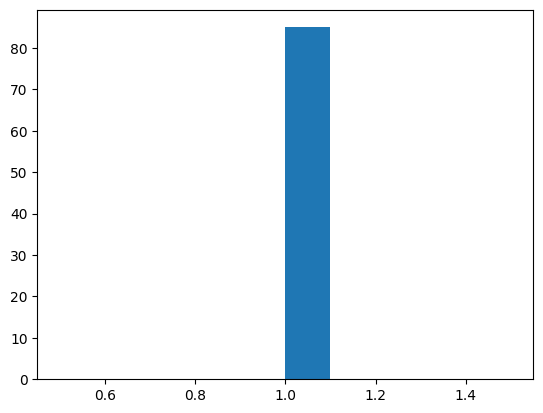

In [161]:
plt.hist(rows_with_95_percent_same_value.loc['Q58'])

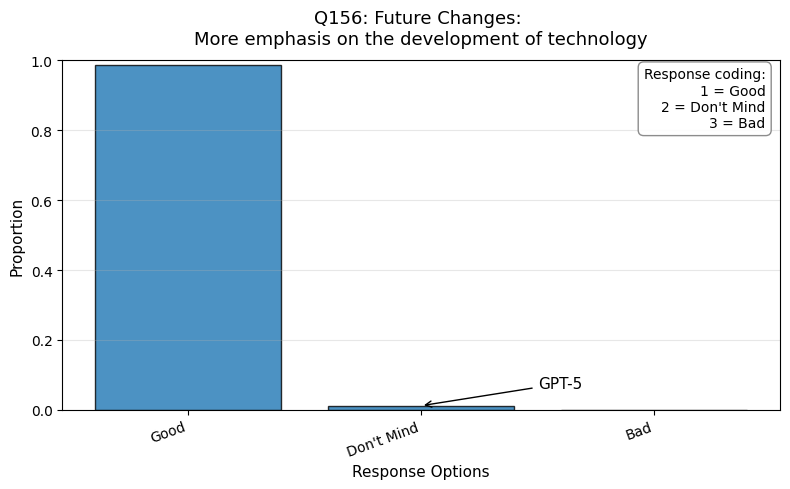

In [157]:
import matplotlib.pyplot as plt
import pandas as pd

q_code = "Q44"
q_text = "Future Changes: \nMore emphasis on the development of technology"
options = [
    "Good",
    "Don't Mind",
    "Bad"  
]

# Extract values from your dataframe (rows=questions, columns=respondents)
values = response_df.loc[q_code]

# Calculate proportions
prop = values.value_counts(normalize=True).reindex(range(1,4), fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(1, 4), prop, edgecolor="black", alpha=0.8)

# X-axis labels
ax.set_xticks(range(1, 4))
ax.set_xticklabels(options, rotation=20, ha="right")
ax.set_ylabel("Proportion", fontsize=11)
ax.set_xlabel("Response Options", fontsize=11)
ax.set_title(f"Q156: {q_text}", fontsize=13, pad=12)
ax.set_ylim(0, 1)

# Add survey coding annotation in top-right corner
annotation_text = (
    "Response coding:\n"
    "1 = Good\n"
    "2 = Don't Mind\n"
    "3 = Bad"
)
ax.annotate(
    annotation_text,
    xy=(0.98, 0.98),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
)

# Add point annotation for option 2
option_index = 2  # option 2
bar_height = prop[option_index]
ax.annotate(
    "GPT-5",
    xy=(option_index, bar_height),        # point to top of bar
    xytext=(option_index + 0.5, bar_height + 0.05),  # offset text
    arrowprops=dict(facecolor='black', arrowstyle="->"),
    fontsize=11
)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig('./gpt5_experiment_q44.png', transparent = True)
plt.show()


#### Compare with Prior Experiment Results

In [84]:
with open('./data/LLM_exp_result/gpt4_t1_r1.json', "r") as f:
    baseline_dict = json.load(f)

In [85]:
baseline_df = pd.DataFrame(baseline_dict['country_values'])

In [86]:
baseline_df

,Spain,Turkey,Tunisia,Germany,Ukraine,Trinidad and Tobago,Bolivia,Colombia,Czech Republic,Libya,...,Romania,Egypt,Lebanon,Nicaragua,Mongolia,Indonesia,Georgia,India,Yemen,model
Q7,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Q8,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Q9,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Q10,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Q11,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q25,2,2,2,2,2,2,2,2,2,1,...,2,2,2,2,2,2,2,2,1,2
Q26,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Q57,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Q240,5,5,5,5,5,5,4,5,5,6,...,5,5,5,5,5,5,5,5,7,5


In [14]:
response_df

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
Q64,1,1,2,1,1,1,2,1,2,3,...,2,2,1,1,2,2,2,1,2,2
Q65,2,2,4,2,2,1,3,2,2,2,...,2,1,3,2,1,1,3,1,1,2
Q66,3,3,2,3,3,3,3,3,3,3,...,3,3,3,3,3,4,3,3,3,3
Q67,3,3,2,3,3,2,3,3,3,3,...,3,2,3,3,2,3,2,3,3,3
Q68,3,2,3,3,3,3,3,3,2,3,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,1,2,1,0,2,2,0,2,2,2,...,2,1,2,2,0,1,1,2,2,2
Q126,1,1,0,2,1,2,0,1,0,1,...,1,2,0,2,0,1,0,0,1,0
Q127,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,1,2,2,2,2,2
Q128,2,2,0,2,1,2,0,2,0,1,...,2,2,0,2,0,1,1,2,0,0


In [15]:
common_items = list(set(baseline_df.index).intersection(set(response_df.index)))
len(common_items)

53

In [16]:
common_countries = list(set(baseline_df.columns).intersection(set(response_df.columns)))
len(common_countries)

85

Let's compare these 53 items:

In [83]:
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt

def check_similarity(model, df_lst, pairs, pair_labels):
    """
    Compare models using Euclidean distance, cosine similarity,
    and Pearson correlation on shared index and columns only.
    """

    results = {
        "distance": {p: [] for p in pairs},
        "similarity": {p: [] for p in pairs},
        "correlation": {p: [] for p in pairs},
        "spearman": {p: [] for p in pairs},
    }

    pearson_defined = {p: 0 for p in pairs}
    pearson_total = {p: 0 for p in pairs}
    low_corr = []
    undefined_corr = []

    for p in pairs:
        df1, df2 = df_lst[p[0]], df_lst[p[1]]

        # shared rows and columns
        shared_idx = df1.index.intersection(df2.index)
        shared_cols = df1.columns.intersection(df2.columns)

        if len(shared_idx) == 0 or len(shared_cols) == 0:
            print(f"Skipping {p}: no shared index or columns")
            continue

        print(f"{p}: {len(shared_idx)} shared rows × {len(shared_cols)} shared columns")

        for c in shared_cols:
            r1 = df1.loc[shared_idx, c].values.reshape(1, -1)
            r2 = df2.loc[shared_idx, c].values.reshape(1, -1)

            # Euclidean distance
            dist = euclidean_distances(r1, r2)[0, 0]
            results["distance"][p].append(dist)

            # Cosine similarity
            sim = cosine_similarity(r1, r2)[0, 0]
            results["similarity"][p].append(sim)

            # Pearson correlation
            x = r1.ravel()
            y = r2.ravel()

            pearson_total[p] += 1
            if np.std(x) == 0 or np.std(y) == 0:
                corr = np.nan
                undefined_corr.append(c)
            else:
                corr, _ = pearsonr(x, y)
                pearson_defined[p] += 1

            if corr < 0.2:
                print(f"{c}: {corr}")
                low_corr.append(c)

            results["correlation"][p].append(corr)

            # ---- Spearman ----
            sp_corr, _ = spearmanr(x, y)
            results["spearman"][p].append(sp_corr)


    # ---- Visualization ----
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    metrics = ["similarity", "correlation", "spearman", "distance"]
    titles = ["Cosine Similarity", "Pearson Correlation", "Spearman Correlation", "Euclidean Distance"]

    for ax, metric, title in zip(axes, metrics, titles):
        for p, label in zip(pairs, pair_labels):
            # if results[metric][p]:
            #     ax.plot(sorted(results[metric][p]), label=label)
            vals = np.array(results[metric][p])
            vals = vals[~np.isnan(vals)]

            ax.plot(np.sort(vals), label=label)

        means = [
            np.nanmean(results[metric][p])
            for p in pairs if results[metric][p]
        ]
        if metric == "correlation":
            text = "\n".join(
                f"{label}: {pearson_defined[p] / pearson_total[p]:.0%} defined"
                for p, label in zip(pairs, pair_labels)
            )
            ax.text(
                0.02, 0.02, text,
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment="bottom"
            )
        ax.set_title(f"{title} (mean: {np.mean(means):.3f})")
        ax.legend()

    fig.suptitle(model, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    return results, low_corr, undefined_corr


In [87]:
with open('./data/gpt5_t0_r0.json', "r") as f:
    zeroshot_dict = json.load(f)
zeroshot_df = pd.DataFrame(zeroshot_dict['country_values'])

In [96]:
zeroshot_df

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
Q64,1,1,2,1,1,1,2,1,2,3,...,2,2,1,1,2,2,2,1,2,2
Q65,2,2,4,2,2,1,3,2,2,2,...,2,1,3,2,1,1,3,1,1,2
Q66,3,3,2,3,3,3,3,3,3,3,...,3,3,3,3,3,4,3,3,3,3
Q67,3,3,2,3,3,2,3,3,3,3,...,3,2,3,3,2,3,2,3,3,3
Q68,3,2,3,3,3,3,3,3,2,3,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,1,2,1,0,2,2,0,2,2,2,...,2,1,2,2,0,1,1,2,2,2
Q126,1,1,0,2,1,2,0,1,0,1,...,1,2,0,2,0,1,0,0,1,0
Q127,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,1,2,2,2,2,2
Q128,2,2,0,2,1,2,0,2,0,1,...,2,2,0,2,0,1,1,2,0,0


In [108]:
with open('./data/gpt5_cot.json', "r") as f:
    cot_dict = json.load(f)
cot_df = pd.DataFrame(cot_dict['country_values'])

In [109]:
cot_df

,Ecuador,Uruguay,Canada,Brazil,Tunisia,Philippines,Estonia,Ukraine,Peru,United States,...,Russia,Kenya,Qatar,Bolivia,Slovakia,Armenia,Morocco,Japan,Palestine,model
Q64,2.0,3.0,3.0,2.0,2.0,1.0,4.0,2.0,1.0,2.0,...,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0
Q65,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,...,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,4.0,2.0
Q66,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
Q67,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
Q68,3.0,2.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,4.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0
Q126,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,2.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0
Q127,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Q128,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,2.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0


In [89]:
with open('./data/gpt5_web.json', "r") as f:
    web_dict = json.load(f)
web_df = pd.DataFrame(web_dict['country_values'])

In [98]:
web_df

,Ecuador,Uruguay,Canada,Brazil,Tunisia,Philippines,Estonia,Ukraine,Peru,United States,...,Russia,Kenya,Qatar,Bolivia,Slovakia,Armenia,Morocco,Japan,Palestine,model
Q64,1.0,3.0,2.0,1.0,2.0,1.0,4.0,2.0,2.0,2.0,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0
Q65,2.0,3.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,...,1.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,3.0,2.0
Q66,3.0,2.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,...,3.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
Q67,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,...,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
Q68,3.0,2.0,3.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0
Q126,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,2.0,2.0,1.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0
Q127,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Q128,1.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,...,2.0,2.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,0.0


('zeroshot', 'cot'): 162 shared rows × 85 shared columns
('zeroshot', 'web'): 162 shared rows × 85 shared columns
('cot', 'web'): 162 shared rows × 85 shared columns


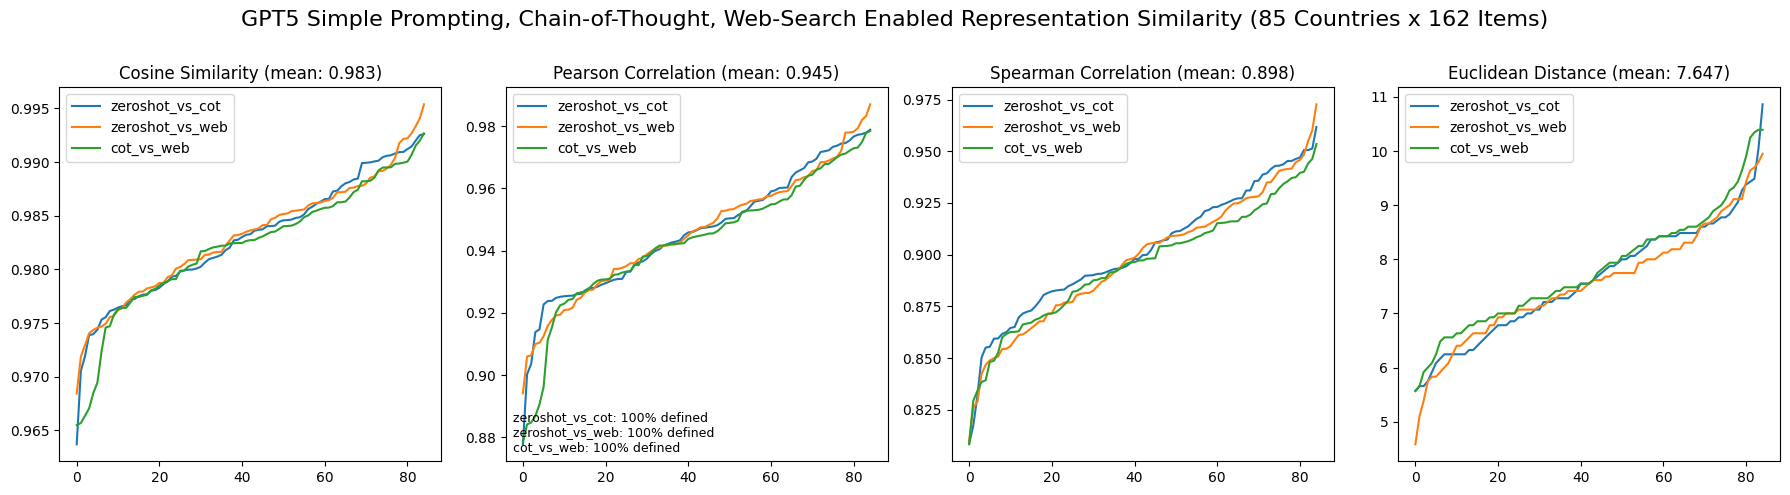

In [112]:
from itertools import combinations

df_lst = {
    # "baseline": baseline_df,
    "zeroshot": zeroshot_df,
    "cot": cot_df,
    "web": web_df,

}

# all key pairs
pairs = list(combinations(df_lst.keys(), 2))

# pair labels
pair_labels = [f"{a}_vs_{b}" for a, b in pairs]


results, low_corr, undefined_corr = check_similarity(
    model="GPT5 Simple Prompting, Chain-of-Thought, Web-Search Enabled Representation Similarity (85 Countries x 162 Items)",
    df_lst=df_lst,
    pairs=pairs,
    pair_labels=pair_labels
)


### Web-Search Agent

### Science Technology Questions

In [33]:
with open('./data/gpt5_extra.json', "r") as f:
    response_dict = json.load(f)

In [34]:
df = pd.DataFrame(response_dict['country_values'])

In [35]:
df

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
Q158,8,8,8,8,8,8,9,8,8,8,...,8,9,7,7,9,8,9,8,8,8
Q159,8,8,8,7,8,8,8,8,8,7,...,7,8,6,6,9,8,8,7,8,8
Q160,7,7,4,7,6,6,3,6,3,3,...,6,3,6,7,3,6,3,6,4,4
Q161,6,6,3,6,5,4,2,5,2,3,...,3,3,3,6,2,4,2,5,3,3
Q162,2,3,2,2,3,3,2,3,3,2,...,2,2,2,3,2,3,2,3,2,2
Q163,8,8,8,7,8,8,9,8,8,7,...,8,8,7,7,9,8,8,8,8,8


In [36]:
import pandas as pd

def reverse_code_questions(df, questions_to_reverse, scale_max=10):
    """
    Reverse-code specified questions in a DataFrame.

    Parameters:
    - df: pd.DataFrame, rows = questions, columns = respondents
    - questions_to_reverse: list of question IDs/labels to reverse-code
    - scale_max: maximum value on the scale (default 10)

    Returns:
    - df_rev: pd.DataFrame with reverse-coded questions in place
    """
    df_rev = df.copy()
    for q in questions_to_reverse:
        if q in df_rev.index:
            df_rev.loc[q] = scale_max + 1 - df_rev.loc[q]  # reverse coding
        else:
            print(f"Warning: {q} not found in DataFrame index.")
    return df_rev


In [37]:
df_rev = reverse_code_questions(df, questions_to_reverse=['Q160','Q161','Q162'])
print(df_rev)

      Maldives  Nigeria  Andorra  Libya  Ethiopia  Tajikistan  Macao  Turkey  \
Q158         8        8        8      8         8           8      9       8   
Q159         8        8        8      7         8           8      8       8   
Q160         4        4        7      4         5           5      8       5   
Q161         5        5        8      5         6           7      9       6   
Q162         9        8        9      9         8           8      9       8   
Q163         8        8        8      7         8           8      9       8   

      Canada  United Kingdom  ...  Greece  Russia  Palestine  Yemen  Vietnam  \
Q158       8               8  ...       8       9          7      7        9   
Q159       8               7  ...       7       8          6      6        9   
Q160       8               8  ...       5       8          5      4        8   
Q161       9               8  ...       8       8          8      5        9   
Q162       8               9  ...      

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity (columns as vectors)
similarity_cosine = pd.DataFrame(
    cosine_similarity(df.T),  # transpose so columns become rows
    index=df.columns,
    columns=df.columns
)

print(similarity_cosine)


           Maldives   Nigeria   Andorra     Libya  Ethiopia  Tajikistan  \
Maldives   1.000000  0.998275  0.971105  0.997828  0.995084    0.990126   
Nigeria    0.998275  1.000000  0.970534  0.996532  0.997307    0.992586   
Andorra    0.971105  0.970534  1.000000  0.959567  0.984921    0.989599   
Libya      0.997828  0.996532  0.959567  1.000000  0.990481    0.984135   
Ethiopia   0.995084  0.997307  0.984921  0.990481  1.000000    0.998211   
...             ...       ...       ...       ...       ...         ...   
Belarus    0.990126  0.992586  0.989599  0.984135  0.998211    1.000000   
Hong Kong  0.940461  0.940071  0.993351  0.927900  0.961637    0.970227   
Peru       0.994488  0.997044  0.980146  0.992000  0.998469    0.996072   
Ukraine    0.971105  0.970534  1.000000  0.959567  0.984921    0.989599   
model      0.971105  0.970534  1.000000  0.959567  0.984921    0.989599   

              Macao    Turkey    Canada  United Kingdom  ...    Greece  \
Maldives   0.937583  0.99

In [39]:
df_rev.describe()

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
count,6.00,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,7.00,6.833333,8.000000,6.666667,7.166667,7.333333,8.666667,7.166667,8.166667,7.833333,...,7.500000,8.333333,7.000000,6.166667,8.833333,7.333333,8.500000,7.000000,8.000000,8.000000
std,2.00,1.834848,0.632456,1.861899,1.329160,1.211060,0.516398,1.329160,0.408248,0.752773,...,1.378405,0.516398,1.414214,1.471960,0.408248,1.211060,0.547723,1.264911,0.632456,0.632456
min,4.00,4.000000,7.000000,4.000000,5.000000,5.000000,8.000000,5.000000,8.000000,7.000000,...,5.000000,8.000000,5.000000,4.000000,8.000000,5.000000,8.000000,5.000000,7.000000,7.000000
25%,5.75,5.750000,8.000000,5.500000,6.500000,7.250000,8.250000,6.500000,8.000000,7.250000,...,7.250000,8.000000,6.250000,5.250000,9.000000,7.250000,8.000000,6.250000,8.000000,8.000000
50%,8.00,8.000000,8.000000,7.000000,8.000000,8.000000,9.000000,8.000000,8.000000,8.000000,...,8.000000,8.000000,7.000000,6.500000,9.000000,8.000000,8.500000,7.500000,8.000000,8.000000
75%,8.00,8.000000,8.000000,7.750000,8.000000,8.000000,9.000000,8.000000,8.000000,8.000000,...,8.000000,8.750000,7.750000,7.000000,9.000000,8.000000,9.000000,8.000000,8.000000,8.000000
max,9.00,8.000000,9.000000,9.000000,8.000000,8.000000,9.000000,8.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,8.000000,9.000000,8.000000,9.000000,8.000000,9.000000,9.000000


In [40]:
# 1️⃣ Transpose so rows = respondents, columns = questions for seaborn
df_t = df_rev.T
df_t

,Q158,Q159,Q160,Q161,Q162,Q163
Maldives,8,8,4,5,9,8
Nigeria,8,8,4,5,8,8
Andorra,8,8,7,8,9,8
Libya,8,7,4,5,9,7
Ethiopia,8,8,5,6,8,8
...,...,...,...,...,...,...
Belarus,8,8,5,7,8,8
Hong Kong,9,8,8,9,9,8
Peru,8,7,5,6,8,8
Ukraine,8,8,7,8,9,8


In [41]:
question_text = {
    'Q158': "Science and technology are making our lives healthier, easier, and more comfortable.",
    'Q159': "Because of science and technology, there will be more opportunities for the next generation.",
    'Q160': "(Reversed) We depend too much on science and not enough on faith.",
    'Q161': "(Reversed) One of the bad effects of science is that it breaks down people’s ideas of right and wrong.",
    'Q162': "(Reversed) It is not important for me to know about science in my daily life.",
    'Q163': "All things considered, is the world better or worse off because of science and technology?"
}

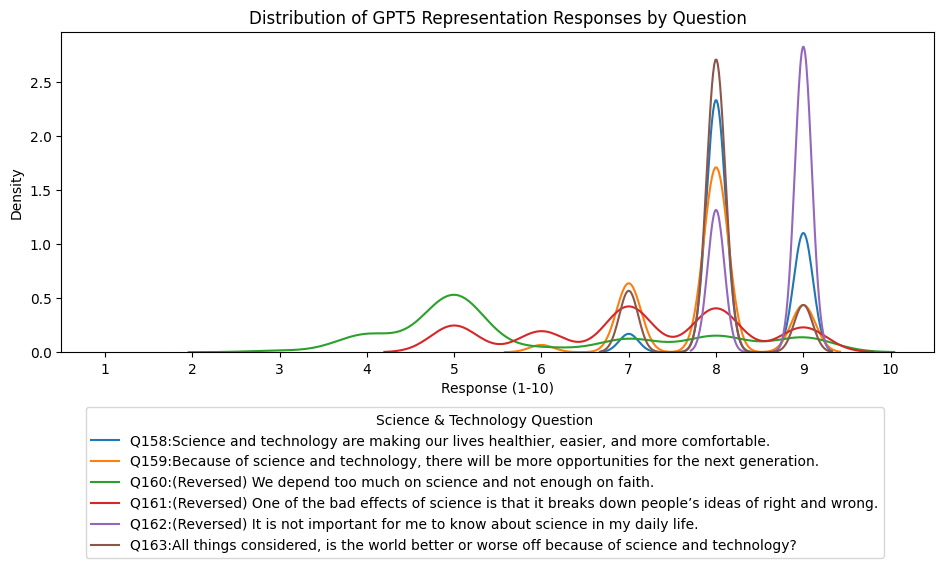

In [65]:
# 2️⃣ Plot KDE for each question
plt.figure(figsize=(10,6))
for question in df_t.columns:
    sns.kdeplot(df_t[question], label=f'{question}:{question_text[question]}', bw_adjust=0.5)  # bw_adjust controls smoothness

plt.title("Distribution of GPT5 Representation Responses by Question")
plt.xlim(0.5, 10.5)
plt.xticks(range(1, 11, 1))
plt.xlabel("Response (1-10)")
plt.ylabel("Density")
plt.legend(title="Science & Technology Question", bbox_to_anchor=(0.02, -0.15), loc='upper left')  # place legend outside
plt.tight_layout()
plt.savefig('./images/gpt5_science_tech_attitude.png', dpi = 300)
plt.show()

Real responses

In [48]:
wave_7 = pd.read_csv('./data/WVS_Wave_7_sci_tech.csv')

In [49]:
codes = {'Q158':'E217',
         'Q159':'E218',
         'Q160':'E220',
         'Q161':'I001',
         'Q162':'I002',
         'Q163':'E234'
}

In [60]:
codes = {v: k for k, v in codes.items()}

In [61]:
codes

{'E217': 'Q158',
 'E218': 'Q159',
 'E220': 'Q160',
 'I001': 'Q161',
 'I002': 'Q162',
 'E234': 'Q163'}

In [50]:
countries = wave_7['COUNTRY_ALPHA'].unique()

In [51]:
for item in list(codes.values()):
    for c in countries:
        # Select the country and item
        mask = (wave_7['COUNTRY_ALPHA'] == c)
        
        # Compute mean ignoring negative values
        mean_val = wave_7.loc[mask & (wave_7[item] >= 0), item].mean(skipna=True)
        
        # Replace negative values with the mean
        wave_7.loc[mask & (wave_7[item] < 0), item] = mean_val

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_15105/1176486423.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.557768924302789' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wave_7.loc[mask & (wave_7[item] < 0), item] = mean_val
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_15105/1176486423.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.291126620139582' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wave_7.loc[mask & (wave_7[item] < 0), item] = mean_val
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_15105/1176486423.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.145145145145145' has dtype incompati

In [59]:
real_response_avg_df = wave_7.groupby('COUNTRY_ALPHA').mean()
real_response_avg_df

,E217,E218,E220,I001,I002,E234
COUNTRY_ALPHA,,,,,,
AND,7.557769,7.291127,6.145145,5.386386,4.107570,6.851594
ARG,7.522796,7.715606,6.490664,5.416216,5.202442,6.400404
ARM,8.659802,8.991722,7.491568,7.183692,4.134378,7.103161
AUS,7.374513,7.068966,3.921448,3.820112,3.891982,7.849888
BGD,8.714167,8.685000,6.420000,6.089167,4.213333,8.322500
...,...,...,...,...,...,...
USA,7.251362,7.149260,4.637495,4.110764,3.795791,7.561280
UZB,7.146916,7.479352,5.753159,4.764310,4.248322,8.299096
VEN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
import pandas as pd

def reverse_code_questions(df, questions_to_reverse, scale_max=10):
    """
    Reverse-code specified questions in a DataFrame.

    Parameters:
    - df: pd.DataFrame, rows = questions, columns = respondents
    - questions_to_reverse: list of question IDs/labels to reverse-code
    - scale_max: maximum value on the scale (default 10)

    Returns:
    - df_rev: pd.DataFrame with reverse-coded questions in place
    """
    df_rev = df.copy()
    for q in questions_to_reverse:
        if q in df_rev.index:
            df_rev.loc[q] = scale_max + 1 - df_rev.loc[q]  # reverse coding
        else:
            print(f"Warning: {q} not found in DataFrame index.")
    return df_rev

real_response_avg_df = reverse_code_questions(real_response_avg_df.T, ['E220', 'I001', 'I002'])

In [70]:
real_response_avg_df

COUNTRY_ALPHA,AND,ARG,ARM,AUS,BGD,BOL,BRA,CAN,CHL,CHN,...,TUN,TUR,TWN,UKR,URY,USA,UZB,VEN,VNM,ZWE
E217,7.557769,7.522796,8.659802,7.374513,8.714167,6.398221,6.711401,7.339721,6.417957,8.668885,...,7.474087,7.333751,7.399836,7.662075,6.907895,7.251362,7.146916,NaN,8.151667,8.200663
E218,7.291127,7.715606,8.991722,7.068966,8.685000,7.069906,7.126794,7.439522,6.875776,8.554149,...,6.833613,7.441238,6.956664,7.961820,7.414387,7.149260,7.479352,NaN,8.347500,8.119701
E220,4.854855,4.509336,3.508432,7.078552,4.580000,4.255234,6.767784,6.895968,4.864461,5.550401,...,6.204849,5.483219,5.441537,4.814424,4.378741,6.362505,5.246841,NaN,4.740000,5.497100
I001,5.613614,5.583784,3.816308,7.179888,4.910833,4.323544,5.761514,6.627178,5.175457,6.132550,...,5.499112,5.461008,5.713818,5.248195,6.056902,6.889236,6.235690,NaN,4.935000,5.332498
I002,6.892430,5.797558,6.865622,7.108018,6.786667,5.352621,6.472534,6.702091,5.725263,8.417667,...,6.836425,6.042760,7.018822,5.365225,6.015369,7.204209,6.751678,NaN,5.665833,6.976783
E234,6.851594,6.400404,7.103161,7.849888,8.322500,5.544603,6.223126,7.290194,5.933747,8.640562,...,5.651629,6.874055,6.988553,7.658085,6.596741,7.561280,8.299096,NaN,8.345000,7.544398


In [53]:
df_ctry_info = pd.read_csv('./data/WVS_country_info.csv')
wv7_countries = list(df_ctry_info[df_ctry_info['wv_7'] == 1]['country'].values)
abr2ctry = {abr: ctry for abr, ctry in zip(df_ctry_info.abr, df_ctry_info.country)}
continents = ['Oceania','Africa','Asia','Europe','North America','South America']
ctry2continent = {ctry: continent for ctry, continent in zip(df_ctry_info.country, df_ctry_info.continent)}

In [73]:
real_response_avg_df.T

,E217,E218,E220,I001,I002,E234
COUNTRY_ALPHA,,,,,,
AND,7.557769,7.291127,4.854855,5.613614,6.892430,6.851594
ARG,7.522796,7.715606,4.509336,5.583784,5.797558,6.400404
ARM,8.659802,8.991722,3.508432,3.816308,6.865622,7.103161
AUS,7.374513,7.068966,7.078552,7.179888,7.108018,7.849888
BGD,8.714167,8.685000,4.580000,4.910833,6.786667,8.322500
...,...,...,...,...,...,...
USA,7.251362,7.149260,6.362505,6.889236,7.204209,7.561280
UZB,7.146916,7.479352,5.246841,6.235690,6.751678,8.299096
VEN,NaN,NaN,NaN,NaN,NaN,NaN


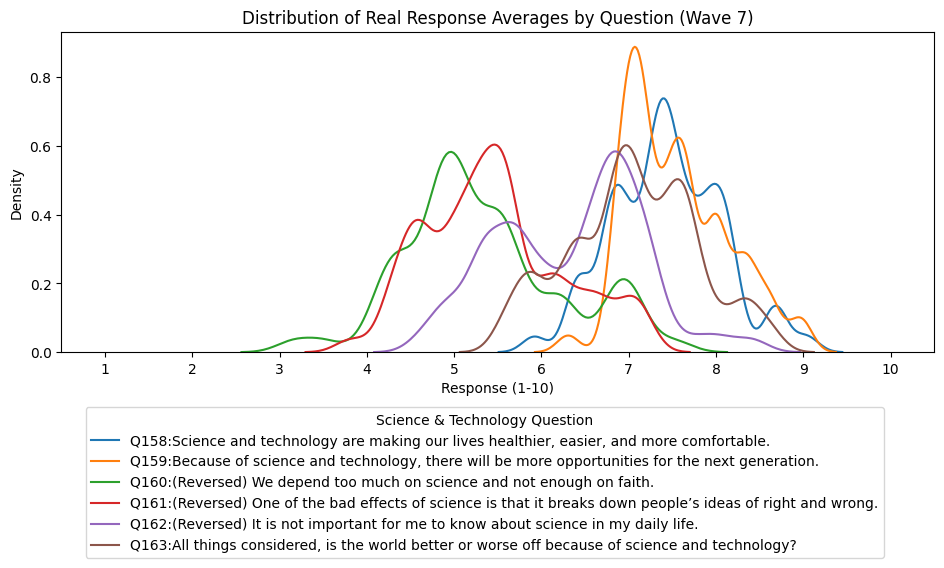

In [74]:
# 2️⃣ Plot KDE for each question
plt.figure(figsize=(10,6))
for question in real_response_avg_df.T.columns:
    sns.kdeplot(real_response_avg_df.T[question], label=f'{codes[question]}:{question_text[codes[question]]}', bw_adjust=0.5)  # bw_adjust controls smoothness

plt.title("Distribution of Real Response Averages by Question (Wave 7)")
plt.xlim(0.5, 10.5)
plt.xticks(range(1, 11, 1))
plt.xlabel("Response (1-10)")
plt.ylabel("Density")
plt.legend(title="Science & Technology Question", bbox_to_anchor=(0.02, -0.15), loc='upper left')  # place legend outside
plt.tight_layout()
plt.savefig('./images/real_avg_science_tech_attitude.png', dpi = 300)
plt.show()